In [73]:
!pip install polars -q
!pip install matplotlib -q

We will use polars library instead of pandas since it has proven to be faster for working with large datasets

# Table of Contents
* [Preparation](#Preparation)
* [Reading files for 9 days](#Reading_files_for_9_days)

## Preparation

In [76]:
import os
import pandas as pd
import polars as pl
from datetime import datetime
from matplotlib import pyplot as plt
pl.Config.set_tbl_rows(-1)
print(f"Доступно ядер в системе: {pl.thread_pool_size()}")

Доступно ядер в системе: 6


In [4]:
dir_path = '/home/jovyan/__AP25RAY/data/events'
items = os.listdir(dir_path)

In [5]:
file_path = str(dir_path + '/' +  items[1])
print(f' The size of the data for one day is {round(os.path.getsize(file_path) / 100 ** 3)} MB')

 The size of the data for one day is 311 MB


In [6]:
size = 0
for i in items[1:10]:
    file_path = str(dir_path + '/' + i)
    file_size = os.path.getsize(file_path)
    size += file_size
print(f'The size of the data for 10 days is {round(size / 1000 ** 3, 3)} GB')

The size of the data for 10 days is 3.772 GB


## Reading_files_for_9_days

In [7]:
%%time
dfs = []
for i in items[1:10]:
    file_path = str(dir_path + '/' + i)
    df = pl.read_csv(
        file_path,         
        has_header=True,         
        infer_schema_length=1000,
        ignore_errors=False, 
        schema_overrides={"appmetrica_device_id": pl.UInt64}
    )
    dfs.append(df)
df_week = pl.concat(dfs, how = 'vertical')

CPU times: user 12.5 s, sys: 6.15 s, total: 18.6 s
Wall time: 17.6 s


In [8]:
del(dfs)

In [9]:
df_week.shape

(8551962, 32)

## Data Quality Checks

In [10]:
df_week['profile_id'].null_count()

27031

In [11]:
df_week = df_week.filter(pl.col('profile_id').is_not_null())

In [12]:
df_week['session_id'].null_count()

0

In [13]:
# Session ids are not unique for each user
df_week.group_by('session_id').agg(
    pl.col('profile_id').n_unique()
).sort('profile_id', descending = True).head(5)

session_id,profile_id
i64,u32
10000000001,10354
10000000000,6231
10000000002,5418
10000000003,4751
10000000004,4136


In [14]:
# One profile can have a few installations
fiu =df_week.group_by('profile_id').agg(
    pl.col('installation_id').n_unique()
).sort('installation_id', descending = True).filter(
    pl.col('installation_id') > 1
)
print(fiu.height)

1067


In [15]:
# Most of the users with a few installations installed the app on the same device
df_week.filter(
    pl.col('profile_id').is_in(fiu['profile_id'].unique().to_list())
).group_by('profile_id').agg(
    pl.col('device_type').n_unique()
).sort('device_type', descending = True).head(15)

profile_id,device_type
str,u32
"""GNKpHJDx.1637454914839""",2
"""sIYGKK8c.1632748868386""",2
"""UfEEV5Sd.1571000540396""",2
"""RSgKVIri.1627718394254""",2
"""8fSk6bYJ.1619796216946""",2
"""04qkGqiy.1577641846243""",2
"""UlTkNy5V.1489829297242""",2
"""pbB84Ehj.1495390652973""",2
"""Cfy72Kl8.1590864155667""",2


In [16]:
del(fiu)

**It makes sense to create a column with unique session id for further analysis**

## Transformations

In [17]:
# Transforming the data type
df_week = df_week.with_columns([
    pl.col('event_datetime').str.to_datetime(),
    pl.col('event_receive_datetime').str.to_datetime(),
])

In [ ]:
df_week = df_week.with_columns(
    pl.col('event_datetime').dt.date().alias('day')
)

## Creating custom session ids

- We create a "user_session_id" column which combines profile_id and the order of user's session
- A new session begins if the timeout between sessions is 10 minutes
- We will use both session_id and user_session_id in the analysis

In [19]:
df_week = df_week.sort(['profile_id', 'event_datetime'], descending = False)

In [23]:
df_week = df_week.with_columns(
      pl.col('event_datetime').diff().over('profile_id').dt.total_seconds().alias('time_since_last_event')
)
df_week = df_week.with_columns(
    (pl.col('time_since_last_event') > 1200).fill_null(True).alias('new_session')
)

In [24]:
df_week = df_week.with_columns(
    pl.col('new_session').cum_sum().over('profile_id').alias('session_group')
)

In [29]:
df_week = df_week.with_columns(
    pl.concat_str([
        pl.col('profile_id').cast(pl.Utf8),
        pl.lit('_'),
        pl.col('session_group').cast(pl.Utf8)
    ]).alias('user_session_id')
)

In [32]:
df_week = df_week.drop(['new_session', 'time_since_last_event', 'session_group'])

In [36]:
# Let's compare the features "session_id" and "user_session_id"
print(f"There are {df_week[['session_id', 'profile_id']].n_unique()} session_ids")
print(f"There are {df_week['user_session_id'].n_unique()} user_session_ids")

There are 1250427 session_ids
There are 766786 user_session_ids


The created feature contains half as many unique sessions as the original feature

## Aggregated indicators

In [24]:
# Let's count unique users in our dataset
print(f"There are {df_week['profile_id'].n_unique()} unique users in the app")

There are 331742 unique users in the app


In [33]:
print(f"There are {df_week['user_session_id'].n_unique()} unique sessions in the app")

There are 766786 unique sessions in the app


The average number of actions per user is 25.7


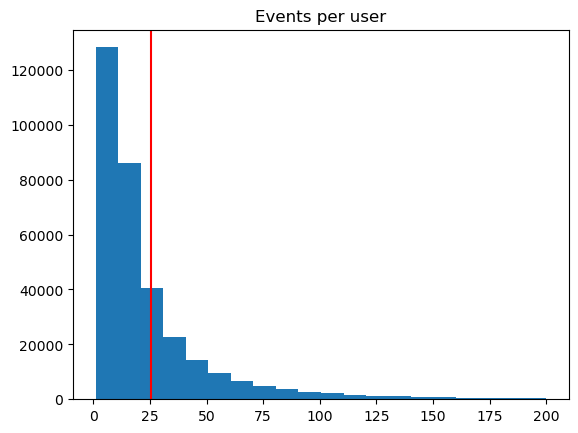

In [93]:
mean_events = df_week.group_by('profile_id').agg(
    pl.col('event_name').count()
)['event_name'].mean()


events_per_user = df_week.group_by('profile_id').agg(
    pl.col('event_name').count()
)
# Removing outliers
events_per_user = events_per_user.filter(
    pl.col('event_name') <= 200
)
plt.hist(events_per_user['event_name'], bins = 20)
plt.title('Events per user');
plt.axvline(mean_events, c = 'red')

print(f'The average number of actions per user is {round(mean_events,2)}')

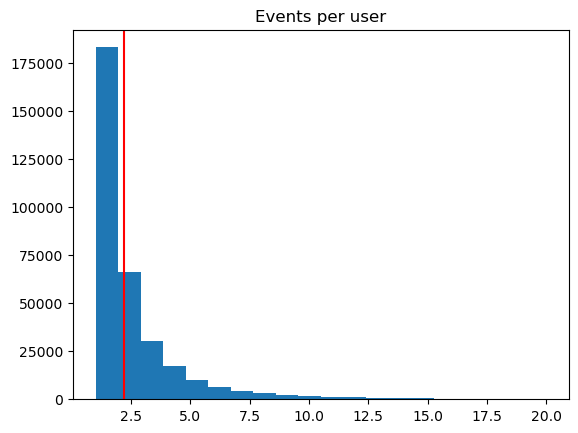

In [106]:
sessions_per_user = df_week.group_by('profile_id').agg(
    pl.col('user_session_id').n_unique()
)
sessions_per_user = sessions_per_user.filter(
    pl.col('user_session_id') <= 20
)
mean_sessions = sessions_per_user['user_session_id'].mean()

plt.hist(sessions_per_user['user_session_id'], bins = 20)
plt.title('Sessions per user')
plt.axvline(mean_sessions, c = 'red');

In [115]:
# Let's take a look at acions per day and sessions per day
mean_actions_per_day = df_week.group_by(['profile_id', 'day']).agg(
    pl.col('event_name').count()
)['event_name'].mean()

mean_session_per_day = df_week.group_by(['profile_id', 'day']).agg(
    pl.col('user_session_id').n_unique()
)['user_session_id'].mean()
print(f'The users have {round(mean_session_per_day, 1)} on average')
print(f'The make {round(mean_actions_per_day, 1)} actions per day on average')

The users have 1.2 on average
The make 13.3 actions per day on average


Text(0.5, 1.0, 'Distribution of events per day')

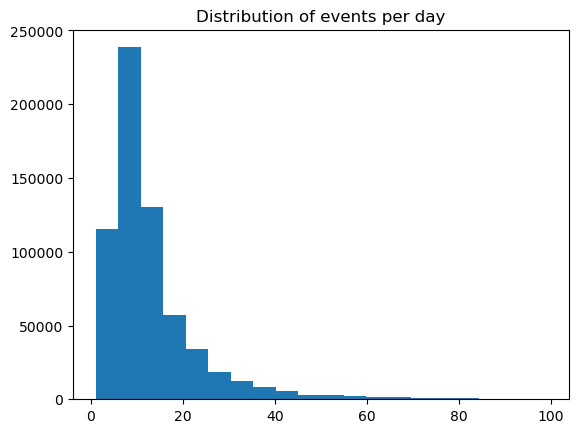

In [122]:
actions_per_day = df_week.group_by(['profile_id', 'day']).agg(
    pl.col('event_name').count()
)
actions_per_day = actions_per_day.filter(
    pl.col('event_name') < 100
)
plt.hist(actions_per_day['event_name'], bins = 20)
plt.title('Distribution of events per day')
plt.

In [25]:
# Let's find users who have actually paid a fine through the app
df_paid = df_week.filter((pl.col('event_name').str.contains('Завешили оплату'))|
              (pl.col('event_name').str.contains('Завершили оплату'))
    )
df_paid.head()

event_datetime,event_json,event_name,event_receive_datetime,event_receive_timestamp,event_timestamp,session_id,installation_id,appmetrica_device_id,city,connection_type,country_iso_code,device_ipv6,device_locale,device_manufacturer,device_model,device_type,google_aid,ios_ifa,ios_ifv,mcc,mnc,operator_name,original_device_model,os_name,os_version,profile_id,windows_aid,app_build_number,app_package_name,app_version_name,application_id,day
datetime[μs],str,str,datetime[μs],i64,i64,i64,str,u64,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,i64,str,str,i64,date
2024-01-01 21:12:48,"""{""From"":""Список""}""","""Мои штрафы/Оплата/Завершили оп…",2024-01-01 20:12:49,1704129169,1704129168,10000000091,"""5a7beb4b26224b68b9fdabdebfcb6e…",1253027513034051897,null,"""cell""","""RU""","""::ffff:85.140.24.250""","""ru_RU""","""Apple""","""iPhone 14 Pro Max""","""phone""",null,"""4313907D-6FA8-4415-BE15-C80A60…","""F189CB36-5358-4B01-A401-887F82…",0,0,null,"""iPhone15,3""","""ios""","""16.2""","""afa318dddc558d019f4e791e93fbb1…",null,770,"""ru.reactivephone.shtrafy""","""4.15""",108955,2024-01-01
2024-01-01 18:51:15,"""{""From"":""Список""}""","""Мои штрафы/Оплата/Завершили оп…",2024-01-01 17:51:16,1704120676,1704120675,10000000226,"""a4b09c79a3c344f98ea58d9271fd66…",17198353800472796506,null,"""cell""","""RU""","""2a03:d000:8684:aea2:ec4c:4fe5:…","""ru_RU""","""Apple""","""iPhone 11""","""phone""",null,"""8B401483-44C2-4718-A4DF-1D34E2…","""EC3AA25B-AD71-4C8B-948D-B87E6A…",0,0,null,"""iPhone12,1""","""ios""","""15.6.1""","""fb9864e43098b7b895f6756f8fa50e…",null,770,"""ru.reactivephone.shtrafy""","""4.15""",108955,2024-01-01
2024-01-01 15:07:42,"""{""From"":""Список""}""","""Мои штрафы/Оплата/Завершили оп…",2024-01-01 14:07:44,1704107264,1704107262,10000000105,"""87af7f06487e4b30957265295234bb…",5323143044857597528,null,"""cell""","""RU""","""::ffff:5.139.244.223""","""ru_RU""","""Apple""","""iPhone 8 Plus""","""phone""",null,null,"""B9761EDF-6713-46D6-A1F2-D0E3D4…",0,0,null,"""iPhone10,5""","""ios""","""16.7.2""","""f1b1972e471f5f93e7b916d5de65b0…",null,770,"""ru.reactivephone.shtrafy""","""4.15""",108955,2024-01-01
2024-01-01 06:03:12,"""{""From"":""Список""}""","""Мои штрафы/Оплата/Завершили оп…",2024-01-01 05:03:19,1704074599,1704074592,10000000219,"""66c5902e67e74aed97f6959678cd3e…",6491243172887891917,null,"""cell""","""RU""","""::ffff:80.83.239.73""","""ru_RU""","""Apple""","""iPhone 11""","""phone""",null,null,"""5C40EBF6-D3E1-41CA-B9BD-C7B219…",0,0,null,"""iPhone12,1""","""ios""","""17.1.2""","""d354748a4a7002d9979e1bf1159139…",null,770,"""ru.reactivephone.shtrafy""","""4.15""",108955,2024-01-01
2024-01-01 15:07:42,"""{""From"":""Список""}""","""Мои штрафы/Оплата/Завешили опл…",2024-01-01 14:07:44,1704107264,1704107262,10000000105,"""87af7f06487e4b30957265295234bb…",5323143044857597528,null,"""cell""","""RU""","""::ffff:5.139.244.223""","""ru_RU""","""Apple""","""iPhone 8 Plus""","""phone""",null,null,"""B9761EDF-6713-46D6-A1F2-D0E3D4…",0,0,null,"""iPhone10,5""","""ios""","""16.7.2""","""f1b1972e471f5f93e7b916d5de65b0…",null,770,"""ru.reactivephone.shtrafy""","""4.15""",108955,2024-01-01


In [26]:
num_all_users = df_week['profile_id'].n_unique()
num_paid_users = df_paid['profile_id'].n_unique()

print(f'There are {num_paid_users} users who paid a fine through the app')
print(f'{round(num_paid_users / num_all_users * 100, 1)}% of all users paid a fine through the app')

There are 2273 users who paid a fine through the app
0.7% of all users paid a fine through the app


In [28]:
sessions_with_payment = df_week.filter(
    pl.col('event_name').str.contains("Завершили оплату") |
    pl.col('event_name').str.contains("Завешили оплату")
).select(['session_id', 'profile_id']).unique()
sessions_without_payment = df_week.join(
    sessions_with_payment,
    on=['session_id', 'profile_id'],
    how='anti' 
).select(['session_id', 'profile_id']).unique()
print(f'{len(sessions_with_payment)} sessions ended in a fine payment')
print(f"This constitutes {round(len(sessions_with_payment) / df_week['profile_id', 'session_id'].n_unique() * 100, 2)}% of all sessions")
print('***' * 30)
print(f'{len(sessions_without_payment)} sessions ended without a fine payment')
print(f"This constitutes {round(len(sessions_without_payment) / df_week['profile_id', 'session_id'].n_unique() * 100, 2)}% of all sessions")

2701 sessions ended in a fine payment
This constitutes 0.22% of all sessions
******************************************************************************************
1247726 sessions ended without a fine payment
This constitutes 99.78% of all sessions


In [31]:
paid_users = df_paid.group_by('profile_id').agg(
    pl.col('session_id').n_unique()
).sort('session_id', descending = True)['profile_id'].to_list()

In [32]:
df_unpaid = df_week.filter(
      ~(pl.col('event_name').str.contains('Завешили оплату')) &
      ~(pl.col('event_name').str.contains('Завершили оплату'))
    )
unpaid_users = df_unpaid.group_by('profile_id').agg(
    pl.col('session_id').n_unique()
).sort('session_id', descending = True)['profile_id'].to_list()

In [100]:
def analyze_user(user_id: int, paid = True):
    user = df_week.filter(pl.col('profile_id') == user_id)
    user = user.unique()
    user = user.sort('event_datetime')
    print(f"The user had {user['session_id'].n_unique()} sessions")
    sessions = user.group_by('session_id').agg(
                pl.len()).sort('session_id')
    for s in sessions['session_id']:
        session = user.filter(pl.col('session_id') == s)
        date = session['event_datetime'][0]
        events = session['event_name'].to_list()
        logs = session['event_json'].to_list()
        print(date)
        for val in zip(events, logs):
            print(val)
        print('\n','***' * 30)
def analyze_session(session_id : int):
    session = df_week.filter(pl.col('session_id') == session_id)
    session = session.sort('event_datetime')
    events = session['event_name'].to_list()
    logs = session['event_json'].to_list()
    for val in zip(events, logs):
        print(val)

In [101]:
analyze_user(paid_users[2], paid = True)

The user had 22 sessions
2024-01-03 01:50:58
('Мои штрафы/Документы/Есть СТС', None)
('Мои штрафы/Проверка/Открыли форму', None)
('Мои штрафы/Документы/Есть ВУ', None)
('Мои штрафы/Документы/Есть документ', None)
('ОСАГО/Увидел', None)

 ******************************************************************************************
2024-01-03 01:52:54
('Мои штрафы/Проверка СТС/Открыли форму', None)
('Мои штрафы/Проверка/Добавить авто', None)

 ******************************************************************************************
2024-01-03 01:55:36
('Проверка/Список штрафов/ГИС ГМП проверена', None)
('Проверка/Список штрафов/ИНН/Показ', '{"From":"Несколько машин","пустой":1}')
('Добавлен документ', '{"Тип":"СТС"}')
('Проверка/Список штрафов', None)
('Мои штрафы/Проверка СТС/Открыли список штрафов', None)
('Проверен документ', '{"Проверка по всем":false,"Число штрафов":0,"Время на крутилке":9.0170309543609619,"Тип":"СТС","Сумма по штрафам":0}')

 *****************************************

## Paid users analysis and comparison with unpaid users

In [33]:
# Let's calculate the average number of sessions for paid users
mean_session_paid = df_week.filter(pl.col('profile_id').is_in(paid_users)).group_by(['profile_id']).agg(
    pl.col('session_id').n_unique()
)['session_id'].mean()
print(mean_session_paid)

5.30136383633964


In [21]:
mean_sessions_unpaid = df_week.filter(pl.col('profile_id').is_in(unpaid_users)).group_by('profile_id').agg(
    pl.col('session_id').n_unique()
)['session_id'].mean()
print(mean_sessions_unpaid)

3.7692755213388716


In [75]:
# Let's calculate the average number of events per session
eps_fine = df_week.join(
    sessions_with_payment.select(['session_id', 'profile_id']),
    on=['session_id', 'profile_id'],
    how='inner'
).group_by(['session_id', 'profile_id']).agg(
    pl.col('event_name').count().alias('total_events')
)
eps_fine_mean = eps_fine.select(
    pl.col('total_events').mean().alias('eps_fine_mean')
).item()

eps_no_fine = df_week.join(
    sessions_without_payment.select(['session_id', 'profile_id']),
    on=['session_id', 'profile_id'],
    how='inner'
).group_by(['session_id', 'profile_id']).agg(
    pl.col('event_name').count().alias('total_events')
)
eps_nofine_mean = eps_no_fine.select(
    pl.col('total_events').mean().alias('eps_no_fine')
).item()


In [76]:
print(f'The average number of events per a session ending with a fine payment is {round(eps_fine_mean, 2)}')
print(f'The average number of events per a session ending without a fine payment is {round(eps_nofine_mean, 2)}')

The average number of events per a session ending with a fine payment is 19.83
The average number of events per a session ending without a fine payment is 6.79


In [82]:
eps_no_fine.head()

session_id,profile_id,total_events
i64,str,u32
10000002468,"""GybqhvYB.1674288274450""",1
10000003887,"""t0fzOBEb.1571072328077""",20
10000000978,"""WnFWk20e.1601806929520""",1
10000000358,"""b4fc5301045217506fdf4b410bc26a…",14
10000001848,"""BhMUithP.1597637414226""",1


In [90]:
eps_no_fine = eps_no_fine.filter(
    pl.col('total_events') <= 50
)

eps_fine = eps_fine.filter(
    pl.col('total_events') <= 50
)

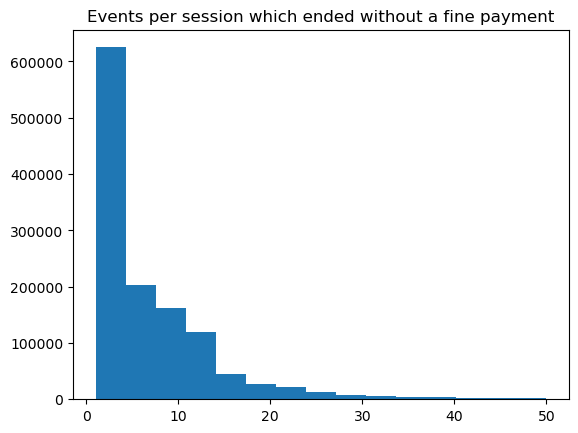

In [94]:
plt.hist(eps_no_fine['total_events'], bins = 15)
plt.title('Events per session which ended without a fine payment');

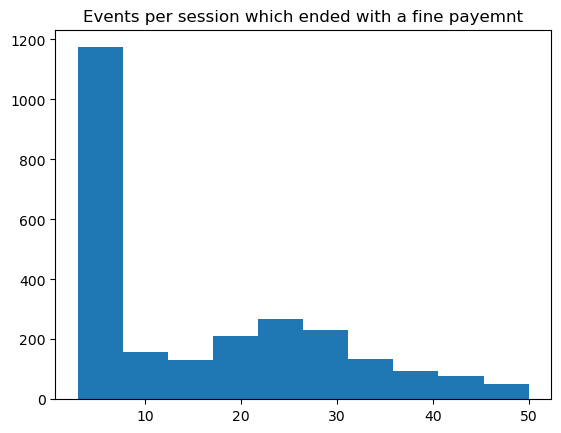

In [95]:
plt.hist(eps_fine['total_events'], bins = 10)
plt.title('Events per session which ended with a fine payemnt');

In [96]:
del(eps_fine, eps_no_fine)

In [137]:
# Let's calculate average duration and duration distributions of sessions with and without fine payment
# And then do the same task for paid and unpaid users
with_fine_dur = df_week.join(
    sessions_with_payment.select(['session_id', 'profile_id']),
    on=['session_id', 'profile_id'],
    how='inner'
).group_by(['session_id', 'profile_id']).agg(
    pl.col('event_datetime').min().alias('session_start'),
    pl.col('event_datetime').max().alias('session_end')
)
with_fine_dur = with_fine_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)
# with_fine_dur = with_fine_dur.filter(
#     pl.col('delta') <= 600
# )

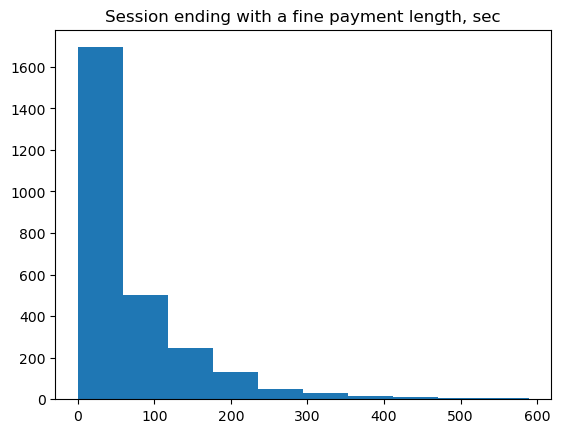

In [109]:
plt.hist(with_fine_dur['delta'], bins = 10)
plt.title('Session ending with a fine payment length, sec');

In [138]:
# Let's calculate average duration and duration distributions of sessions with and without fine payment
# And then do the same task for paid and unpaid users
without_fine_dur = df_week.join(
    sessions_without_payment.select(['session_id', 'profile_id']),
    on=['session_id', 'profile_id'],
    how='inner'
).group_by(['session_id', 'profile_id']).agg(
    pl.col('event_datetime').min().alias('session_start'),
    pl.col('event_datetime').max().alias('session_end')
)
without_fine_dur = without_fine_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)
# without_fine_dur = without_fine_dur.filter(
#     (pl.col('delta') <= 210) &
#     (pl.col('delta') >= 0)
# )

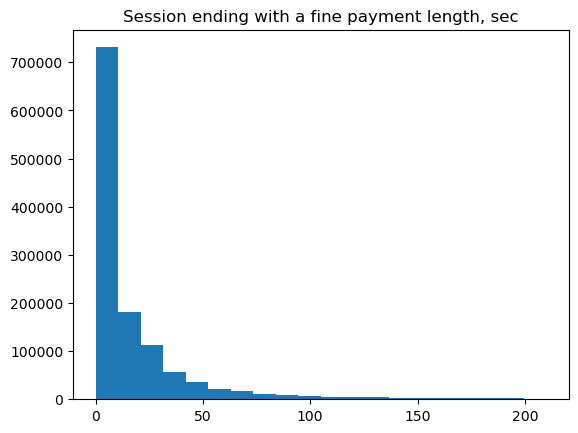

In [128]:
plt.hist(without_fine_dur['delta'], bins = 20)
plt.title('Session ending with a fine payment length, sec');

In [141]:
with_fine_dur_mean = with_fine_dur.select(
    pl.col('delta').median().alias('eps_no_fine')
).item()

without_fine_dur_mean = without_fine_dur.select(
    pl.col('delta').median().alias('eps_no_fine')
).item()


print(f'The length of a session ending with a fine payment is {round(with_fine_dur_mean, 2)} seconds')
print(f'The length of a session ending without a fine payment is {round(without_fine_dur_mean, 2)} seconds')

The length of a session ending with a fine payment is 28.0 seconds
The length of a session ending without a fine payment is 3.0 seconds


Sessions which ended with a fine payment are significantly longer on average and contain more events

In [ ]:
del(without_fine_dur, with_fine_dur, eps_nofine, eps_fine)

In [142]:
paid_dur = df_week.filter(pl.col('profile_id').is_in(paid_users)).group_by(['profile_id', 'session_id']).agg(
    pl.col('event_datetime').max().alias('session_end'),
    pl.col('event_datetime').min().alias('session_start')
)
paid_dur = paid_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)

unpaid_dur = df_week.filter(pl.col('profile_id').is_in(unpaid_users)).group_by(['profile_id','session_id']).agg(
    pl.col('event_datetime').max().alias('session_end'),
    pl.col('event_datetime').min().alias('session_start')
)
unpaid_dur = unpaid_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)

In [23]:
paid_dur.sort('delta', descending = True).head()

profile_id,session_id,session_end,session_start,delta
str,i64,datetime[μs],datetime[μs],i64
"""3513e2500f9398cff636b1c3a2ceb8…",10000000134,2024-01-03 16:43:52,2024-01-02 20:52:03,71509
"""f00bffea800d379460ca8d857efbf2…",10000008360,2024-01-02 11:32:49,2024-01-02 00:59:06,38023
"""96a5ae6dd7e4c4759e666d750399a8…",10000000558,2024-01-08 12:32:51,2024-01-08 09:01:25,12686
"""9fa37cb7aa1e33c3ad02f235fe2fcd…",10000000851,2024-01-08 20:58:21,2024-01-08 20:10:53,2848
"""4f73f0fbbcc26c2e41e06f51b7ee0f…",10000000225,2024-01-05 22:30:23,2024-01-05 21:43:54,2789


In [24]:
print(f" The average session duration for paid users is {paid_dur['delta'].mean()} seconds")
print(f" The average session duration for unpaid users is {unpaid_dur['delta'].mean()} seconds")

 The average session duration for paid users is 53.072033195020744 seconds
 The average session duration for unpaid users is 51.561771298924285 seconds


- The average session duration for unpaid and paid users is almost equal
- The session id is not unique for each users, therefore there might be inaccuracies in the average length of a session calculation

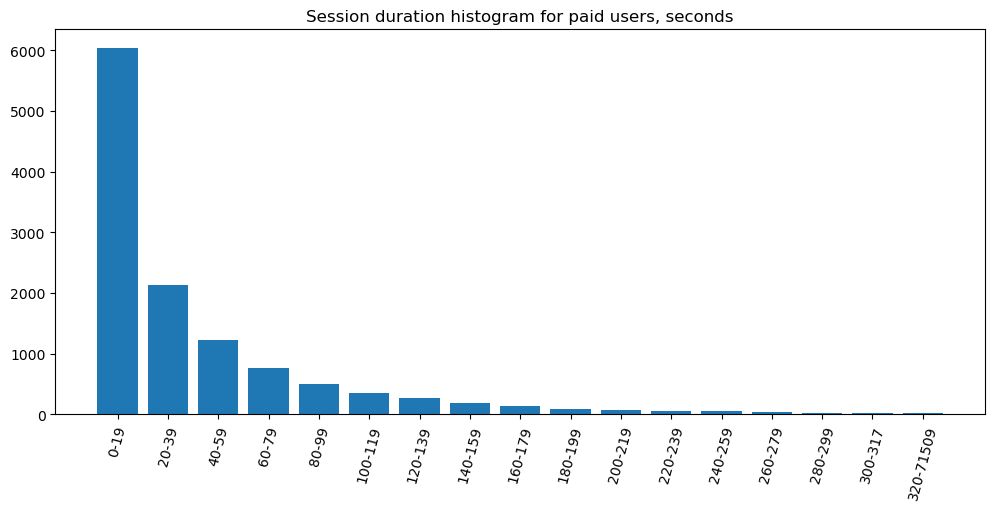

In [67]:
# For paid users
def plot_session_boundaries(df_dur, threshold, title, inverval = 20):
    binned_counts = (
        df_dur.group_by((pl.col("delta") / inverval).floor().alias("bin"))
        .agg([
            pl.len().alias("count"),
            pl.col("delta").min().alias("bin_min"), 
            pl.col("delta").max().alias("bin_max") 
        ])
        .sort("bin")
    )
    threshold = threshold
    binned_counts = binned_counts.with_columns(
        pl.when(pl.col("count") < threshold)
          .then(pl.lit("Other"))
          .otherwise(pl.format("{}-{}", "bin_min", "bin_max"))
          .alias("bin_bounds_str")
    )
    max_other = binned_counts.filter(
        pl.col('bin_bounds_str') == 'Other'
    )['bin_min'].max()
    
    min_other = binned_counts.filter(
        pl.col('bin_bounds_str') == 'Other'
    )['bin_min'].min()
    
    borders = f"{min_other}-{max_other}"
    binned_counts = binned_counts.with_columns(
        pl.col('bin_bounds_str').replace({'Other' : borders})
    )
    
    plt.figure(figsize = (12,5))
    plt.bar(binned_counts['bin_bounds_str'].to_list(), binned_counts['count'].to_list())
    plt.xticks(rotation = 75)
    plt.title(title)
    plt.show()
    
plot_session_boundaries(paid_dur, threshold = 20, 
                        title = 'Session duration histogram for paid users, seconds', inverval = 20)
    

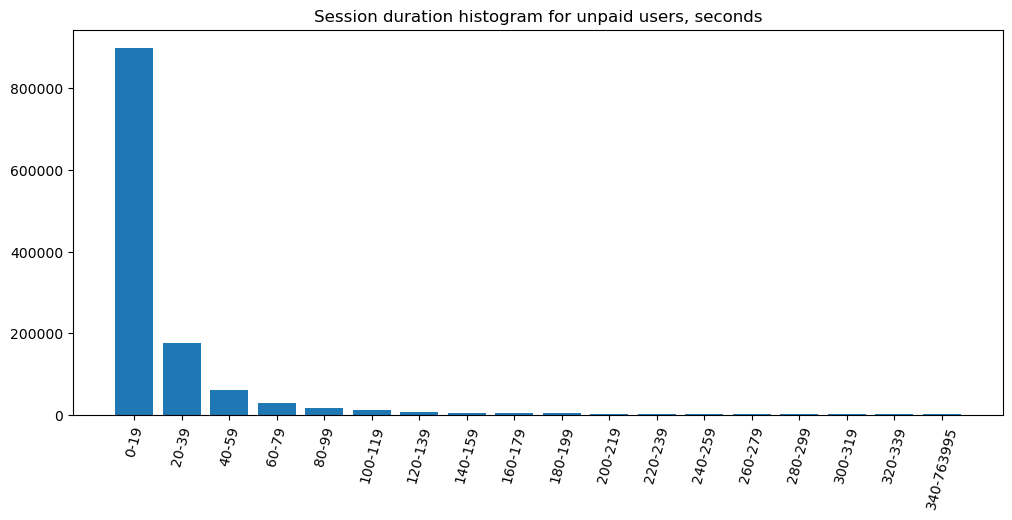

In [97]:
plot_session_boundaries(unpaid_dur, threshold = 1000, 
                        title = 'Session duration histogram for unpaid users, seconds', inverval = 20)

- Most of the sessions for both paid and unpaid users last from 0 to 19 seconds
- No difference in the session duration for two categories of users here

Let's take a look at session durations which ended in a fine payment

In [80]:
fine_sessions = df_week.filter(
    pl.col('session_id').is_in(paid_dur['session_id'].to_list()) &
    pl.col('profile_id').is_in(paid_dur['profile_id'].to_list()) &
    (pl.col('event_name').str.contains('Завершили оплату'))
)['session_id'].unique().to_list()
print(f'There are {len(fine_sessions)} sessions which ended in a fine payment')

There are 898 sessions which ended in a fine payment


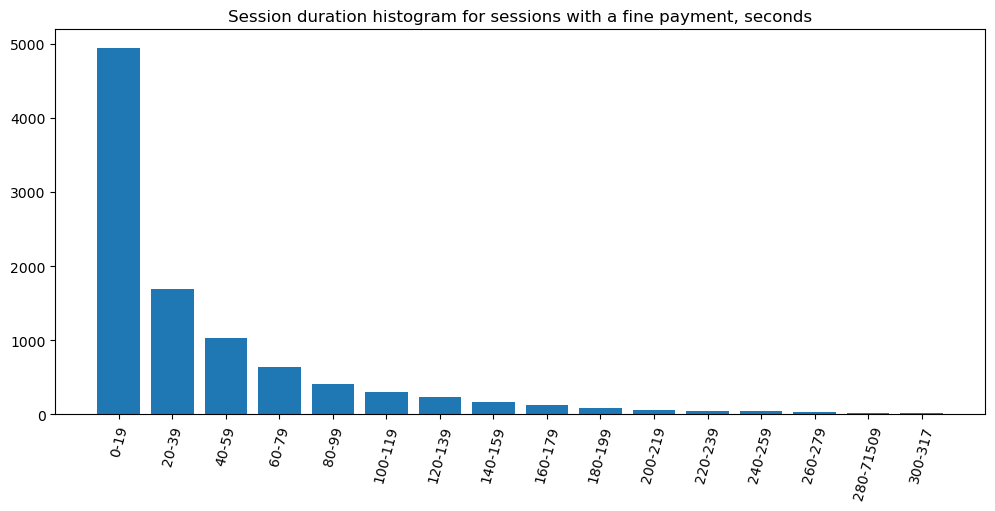

In [87]:
fine_dur = df_week.filter(
    pl.col('profile_id').is_in(paid_users) &
    pl.col('session_id').is_in(fine_sessions)
    ).group_by(['profile_id','session_id']).agg(
    pl.col('event_datetime').max().alias('session_end'),
    pl.col('event_datetime').min().alias('session_start')
)
fine_dur = fine_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)
plot_session_boundaries(fine_dur, threshold = 20, 
                        title = 'Session duration histogram for sessions with a fine payment, seconds', inverval = 20)

**We can try to calcualte the most frequent events in both groups**

In [27]:
event_paid_users = df_week.filter(
    pl.col('profile_id').is_in(paid_users)
)['event_name'].value_counts(normalize = True).sort('proportion', descending = True)
event_unpaid_users = df_week.filter(
    pl.col('profile_id').is_in(unpaid_users)
)['event_name'].value_counts(normalize = True).sort('proportion', descending = True)

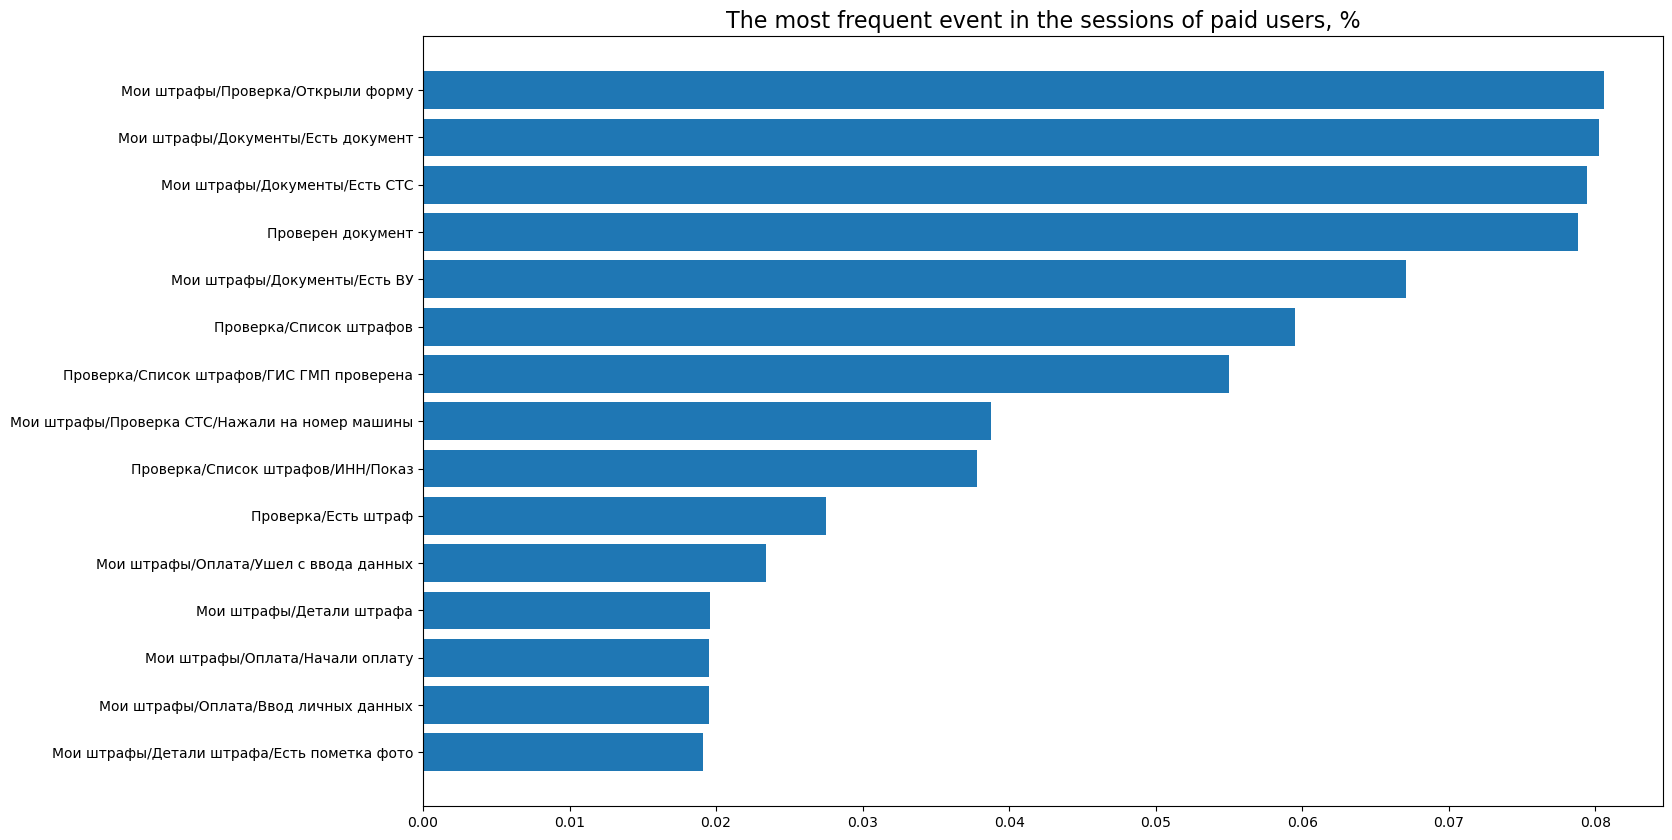

In [115]:
plt.figure(figsize = (16,10))
plt.barh(event_paid_users['event_name'][:15], event_paid_users['proportion'][:15])
plt.gca().invert_yaxis()
plt.title('The most frequent event in the sessions of paid users, %', fontsize = 16)
plt.show()

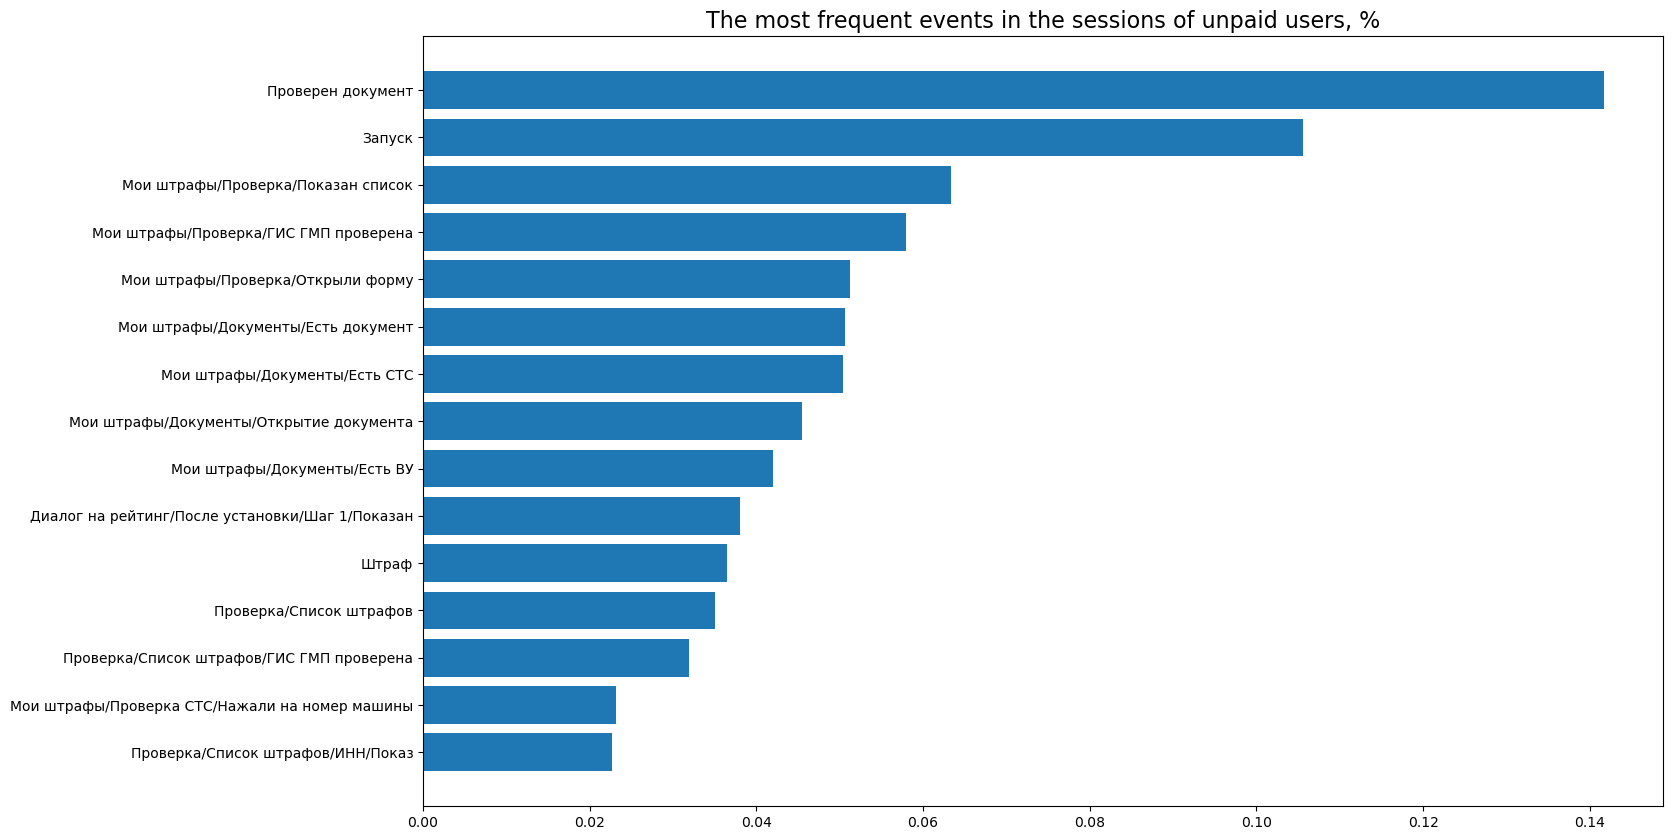

In [114]:
plt.figure(figsize = (16,10))
plt.barh(event_unpaid_users['event_name'][:15], event_unpaid_users['proportion'][:15])
plt.gca().invert_yaxis()
plt.title('The most frequent events in the sessions of unpaid users, %', fontsize = 16)
plt.show()

- Hard to get any insights, it seems like there is no difference between actions of paid and unpaid users
- We can take a look at the actions which lead to fine payment

Let's take a look at the actions which are in sessions which ended with a fine payment

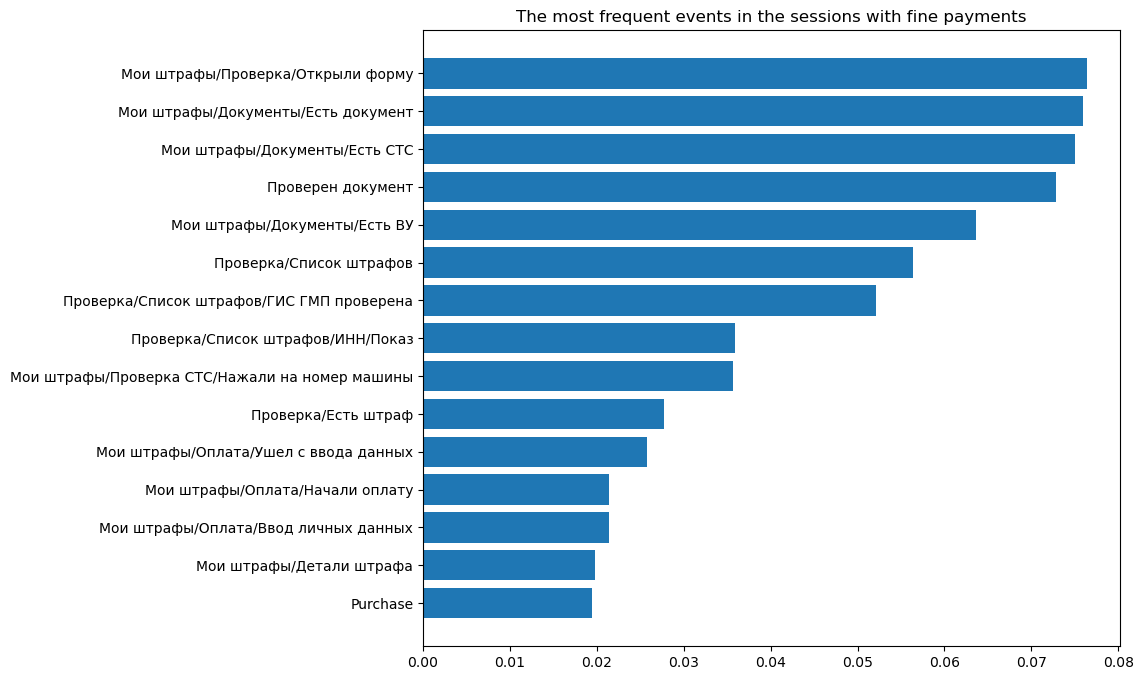

In [137]:


fine_sessions_events = df_week.filter(
    pl.col('profile_id').is_in(sessions_with_payment['profile_id'].to_list()) &
    pl.col('session_id').is_in(sessions_with_payment['session_id'].to_list())
)['event_name'].value_counts(normalize = True).sort('proportion', descending = True)

plt.figure(figsize = (9,8))
plt.barh(fine_sessions_events['event_name'][:15], fine_sessions_events['proportion'][:15])
plt.gca().invert_yaxis()
plt.title('The most frequent events in the sessions with fine payments')
plt.show()

We can try to compare the events in the sessions with and without fine payments

In [ ]:
sessions_without_payments = df_week.join(
    sessions_with_payment.select(['session_id', 'profile_id']).unique(),
    on=['session_id', 'profile_id'],
    how='anti'
)

In [140]:
sessions_without_payments

(8498413, 33)

**We can try to find the actions presceding fine payment**

## User segments

In [69]:
mean_events = df_week.group_by('profile_id').agg(
    pl.col('event_name').count()
)['event_name'].mean()
print(f'The average number of actions per user is {mean_events}')

The average number of actions per user is 25.697472734836108
